### **Project Title: Space-Time Clustering of Mobility Patterns and Air Quality Hotspots for Chicago**

Install Required Packages
and import Libraries

In [4]:
!pip install pygeohash
!pip install folium
!pip install uszipcode
!pip install geopandas
!pip install datascience



In [5]:
from datascience import *
import pandas as pd
import geopandas as gpd
import pygeohash as gh
import numpy as np
from shapely.geometry import Polygon
from shapely.geometry import Point
from geopandas.tools import sjoin
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')


## **1. Data Exploration & Cleaning**

Steps:
Inspect each dataset:

*   Check dtypes format , timestamp formats, intial statistics, spatial coordinates, and column consistency.

*   Remove erroneous coordinates like (0,0).

*   Convert timestamps to a consistent format.

*   Clean and handle missing/null values.




In [7]:
#Read the CSV file containing AQ, Mobility, and chicago data files


# A list of filenames
filenames = [f'chicago_eclipse_data_part_{i}.csv' for i in range(1, 20)]

# Read and concatenate all files
AQ_data = pd.concat([pd.read_csv(file) for file in filenames], ignore_index=True)

#Mobility data
Taxi_trips_data = pd.read_csv('Taxi_Trips_2021.csv')

#Read the GeoJSON file containing neighborhood boundaries into a GeoDataFrame
chicago_polygon = gpd.read_file('chicago_community_boundaries.json')



In [8]:
print("AQ_data",AQ_data.shape)
print("Taxi_trips_data",Taxi_trips_data.shape)
print("chicago_polygon",chicago_polygon.shape)

print("----------------------AQ_data-----------------------")
print(AQ_data.describe())
print(AQ_data.info())
print("------------------Taxi_trips_data-------------------")
print(Taxi_trips_data.describe())
print(Taxi_trips_data.info())
print("------------------chicago_polygon-------------------")
print(chicago_polygon.describe())
print(chicago_polygon.info())

AQ_data (2461089, 16)
Taxi_trips_data (3948045, 23)
chicago_polygon (77, 10)
----------------------AQ_data-----------------------
           DeviceId      Latitude     Longitude          PM25  CalibratedPM25  \
count  2.461089e+06  2.461089e+06  2.461089e+06  2.461089e+06    2.426812e+06   
mean   2.084374e+03  4.184077e+01 -8.768028e+01  9.229856e+00    1.214744e+01   
std    4.530109e+01  9.008293e-02  5.575056e-02  9.291203e+00    6.738110e+00   
min    2.002000e+03  4.164630e+01 -8.780755e+01  0.000000e+00    1.050000e+00   
25%    2.055000e+03  4.177850e+01 -8.772267e+01  4.010680e+00    8.520000e+00   
50%    2.087000e+03  4.184449e+01 -8.768225e+01  7.138157e+00    1.114000e+01   
75%    2.116000e+03  4.190724e+01 -8.764344e+01  1.177193e+01    1.451000e+01   
max    2.214000e+03  4.201305e+01 -8.752829e+01  4.609374e+03    2.445800e+02   

       CalibratedO3  CalibratedNO2            CO   Temperature      Humidity  \
count  2.426812e+06   2.426812e+06  2.460962e+06  2.461089e+

In [9]:
AQ_data

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0


In [10]:
Taxi_trips_data

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,c836b4c700eae1dd3927ff61e38d76a0e86960d0,35057a271731c5b976bda25efe85aa0c1901d0a5fc9ba2...,12/31/2021 11:45:00 PM,01/01/2022 12:15:00 AM,1860.0,26.10,NaN,NaN,76.0,NaN,...,41.0,103.25,Cash,Chicago Independents,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),NaN,NaN,NaN
1,875f9d5a99735dea29b4190436f99191ef029531,222a0a55fe5180e292a8e128804e081fa50b05a0329775...,12/31/2021 11:45:00 PM,12/31/2021 11:45:00 PM,2.0,0.00,NaN,NaN,NaN,NaN,...,1.5,4.75,Cash,Flash Cab,NaN,NaN,NaN,NaN,NaN,NaN
2,aa1826f2f6ed50e88e4db29c48cf89f7bd3e45dc,ab44501ecc8f9ff89c3550d26b04014a7f70640b0691cf...,12/31/2021 11:45:00 PM,01/01/2022 12:00:00 AM,571.0,4.46,NaN,NaN,NaN,NaN,...,4.0,17.50,Cash,Sun Taxi,NaN,NaN,NaN,NaN,NaN,NaN
3,233db55e884187dc6811ff33da52ef2938322fbd,a5409745b45fffb47e16bfb2a6cd085fa7b97b579b42c8...,12/31/2021 11:45:00 PM,01/01/2022 12:00:00 AM,480.0,0.10,NaN,NaN,76.0,NaN,...,7.5,19.50,Credit Card,Taxi Affiliation Services,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),NaN,NaN,NaN
4,23f5d35af1d8cf40cecc4b5db01d9a37981bb6f4,0bea3de3c36237d68b009b24ee3db86c78e9e618a73a3b...,12/31/2021 11:45:00 PM,01/01/2022 01:00:00 AM,4620.0,8.50,NaN,NaN,32.0,8.0,...,2.0,39.50,Cash,Taxi Affiliation Services,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948040,0a86371344f473069f28e43bda5e270fb331dcb4,931225a382fc38a75212f9d358439aec0d9b50fdaf32ad...,01/01/2021 12:00:00 AM,01/01/2021 12:00:00 AM,22.0,0.01,NaN,NaN,14.0,14.0,...,0.0,3.25,Cash,Flash Cab,41.968069,-87.721559,POINT (-87.7215590627 41.968069),41.968069,-87.721559,POINT (-87.7215590627 41.968069)
3948041,4eaf634b3e10271cf3f25e4ca37536992ce2dbae,8c508a77909d4e965c01698b799c7b25ab31d609051979...,01/01/2021 12:00:00 AM,01/01/2021 12:00:00 AM,240.0,0.70,NaN,NaN,8.0,8.0,...,0.0,5.25,Cash,Chicago Independents,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
3948042,855259d1bc129f6370f038aa910067972eeae037,0aba795cd29b34ff868043bc923a341f37c4f6d7afabe4...,01/01/2021 12:00:00 AM,01/01/2021 12:15:00 AM,900.0,0.30,NaN,NaN,28.0,22.0,...,0.0,18.25,Cash,Taxi Affiliation Services,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.922761,-87.699155,POINT (-87.6991553432 41.9227606205)
3948043,f004fd83bf3cb24bb432f77d1b89b7d3c05712ce,be435bc4d6744155b3272e9edded016bd4afb347774701...,01/01/2021 12:00:00 AM,01/01/2021 12:00:00 AM,360.0,2.10,NaN,NaN,56.0,56.0,...,4.0,12.25,Cash,Medallion Leasin,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),41.792592,-87.769615,POINT (-87.7696154528 41.7925923603)


In [11]:
chicago_polygon

,community,area,shape_area,perimeter,area_num_1,area_numbe,comarea_id,comarea,shape_len,geometry
0,DOUGLAS,0,46004621.1581,0,35,35,0,0,31027.0545098,"MULTIPOLYGON (((-87.609 41.845, -87.609 41.845..."
1,OAKLAND,0,16913961.0408,0,36,36,0,0,19565.5061533,"MULTIPOLYGON (((-87.592 41.817, -87.592 41.817..."
2,FULLER PARK,0,19916704.8692,0,37,37,0,0,25339.0897503,"MULTIPOLYGON (((-87.629 41.802, -87.629 41.802..."
3,GRAND BOULEVARD,0,48492503.1554,0,38,38,0,0,28196.8371573,"MULTIPOLYGON (((-87.607 41.817, -87.607 41.817..."
4,KENWOOD,0,29071741.9283,0,39,39,0,0,23325.1679062,"MULTIPOLYGON (((-87.592 41.817, -87.592 41.817..."
...,...,...,...,...,...,...,...,...,...,...
72,MOUNT GREENWOOD,0,75584290.0209,0,74,74,0,0,48665.1305392,"MULTIPOLYGON (((-87.696 41.707, -87.696 41.706..."
73,MORGAN PARK,0,91877340.6988,0,75,75,0,0,46396.419362,"MULTIPOLYGON (((-87.642 41.685, -87.642 41.685..."
74,OHARE,0,371835607.687,0,76,76,0,0,173625.98466,"MULTIPOLYGON (((-87.837 41.986, -87.837 41.986..."
75,EDGEWATER,0,48449990.8397,0,77,77,0,0,31004.8309456,"MULTIPOLYGON (((-87.655 41.998, -87.655 41.998..."


In [12]:
#removing unnecessary data

#######AQ_data######
coulmn_list=['CellSignal','PercentBattery','BatteryLevel','CalibratedNO2','CalibratedO3','CalibratedPM25','DeviceId']
for i in coulmn_list:
    if i in AQ_data.columns:
       AQ_data = AQ_data.drop(columns=[i])
        
#######Taxi_trips_data######
coulmn2_list=['Trip ID','Taxi ID','Trip Seconds','Trip Miles','Pickup Census Tract','Fare','Tips','Tolls','Dropoff Census Tract','Pickup Community Area','Dropoff Community Area','Extras','Trip Total','Payment Type','Company']
for i in coulmn2_list:
    if i in Taxi_trips_data.columns:
       Taxi_trips_data = Taxi_trips_data.drop(columns=[i])
        
#######chicago_polygon######
list_chicago=['area','shape_area','perimeter','area_num_1','area_numbe','comarea_id','comarea','shape_len']
for i in list_chicago:
    if i in chicago_polygon.columns:
        chicago_polygon = chicago_polygon.drop(columns=[i])

#remove erroneous coordinates (0,0), and NaN values
# Convert string datetime to pandas datetime

#######AQ_data######
AQ_data = \
AQ_data[(AQ_data ['Latitude']!=0) & \
       (AQ_data ['Longitude'] !=0)]

AQ_data = AQ_data.dropna(subset=['PM25', 'Temperature', 'Humidity', 'CO'])

AQ_data['ReadingDateTimeUTC'] = pd.to_datetime(AQ_data['ReadingDateTimeUTC'])

print("AQ_data",AQ_data.shape)


#######Taxi_trips_data######

# Remove rows where pickup or dropoff coordinates are NaN or 0
Taxi_trips_data = Taxi_trips_data[
    (Taxi_trips_data['Pickup Centroid Latitude'].notna()) & (Taxi_trips_data['Pickup Centroid Latitude'] != 0) &
    (Taxi_trips_data['Pickup Centroid Longitude'].notna()) & (Taxi_trips_data['Pickup Centroid Longitude'] != 0) &
    (Taxi_trips_data['Dropoff Centroid Latitude'].notna()) & (Taxi_trips_data['Dropoff Centroid Latitude'] != 0) &
    (Taxi_trips_data['Dropoff Centroid Longitude'].notna()) & (Taxi_trips_data['Dropoff Centroid Longitude'] != 0)]

Taxi_trips_data['Trip Start Timestamp'] = pd.to_datetime(Taxi_trips_data['Trip Start Timestamp'])
Taxi_trips_data['Trip End Timestamp'] = pd.to_datetime(Taxi_trips_data['Trip End Timestamp'])


print("Taxi_trips_data",Taxi_trips_data.shape)



AQ_data (2460962, 9)


/var/folders/h2/2gfk43_97tqgvdv7bgtkdx9r0000gn/T/ipykernel_20895/1225811191.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Taxi_trips_data['Trip Start Timestamp'] = pd.to_datetime(Taxi_trips_data['Trip Start Timestamp'])


Taxi_trips_data (3381807, 8)


In [13]:
print("AQ_data time range:")
print("Oldest:", AQ_data['ReadingDateTimeUTC'].min())
print("Newest:", AQ_data['ReadingDateTimeUTC'].max())
AQ_data.head(5)

AQ_data time range:
Oldest: 2021-06-20 00:00:30
Newest: 2021-10-09 23:59:53


,City,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CO,Temperature,Humidity
0,Chicago,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,0.123580,27.383499,55.128479
1,Chicago,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,0.132103,27.079086,55.059814
2,Chicago,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,0.131126,27.079086,55.035400
3,Chicago,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,0.138784,26.945572,54.632568
4,Chicago,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,0.413070,26.828079,53.907776


In [14]:
print("Taxi_trips_data time range:")
print("Oldest Trip Start Timestamp:", Taxi_trips_data['Trip Start Timestamp'].min())
print("Newest Trip Start Timestamp:", Taxi_trips_data['Trip Start Timestamp'].max())
print("Oldest Trip End Timestamp:", Taxi_trips_data['Trip End Timestamp'].min())
print("Newest Trip End Timestamp:", Taxi_trips_data['Trip End Timestamp'].max())
Taxi_trips_data.head(5)

Taxi_trips_data time range:
Oldest Trip Start Timestamp: 2021-01-01 00:00:00
Newest Trip Start Timestamp: 2021-12-31 23:45:00
Oldest Trip End Timestamp: 2021-01-01 00:00:00
Newest Trip End Timestamp: 2022-01-02 13:00:00


,Trip Start Timestamp,Trip End Timestamp,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
4,2021-12-31 23:45:00,2022-01-01 01:00:00,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
8,2021-12-31 23:45:00,2021-12-31 23:45:00,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
9,2021-12-31 23:45:00,2022-01-01 00:15:00,41.965812,-87.655879,POINT (-87.6558787862 41.96581197),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
11,2021-12-31 23:45:00,2021-12-31 23:45:00,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941)
12,2021-12-31 23:45:00,2022-01-01 00:00:00,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)


In [15]:
# Filter Taxi_trips_data to include only trips that occurred within the AQ_data time range
aq_start = AQ_data['ReadingDateTimeUTC'].min()
aq_end = AQ_data['ReadingDateTimeUTC'].max()

Taxi_trips_data_filtered = Taxi_trips_data[
    (Taxi_trips_data['Trip Start Timestamp'] >= aq_start) &
    (Taxi_trips_data['Trip Start Timestamp'] <= aq_end) &
    (Taxi_trips_data['Trip End Timestamp'] >= aq_start) &
    (Taxi_trips_data['Trip End Timestamp'] <= aq_end)]

print("Taxi_trips_data_filtered time range:")
print("Oldest Trip Start Timestamp:", Taxi_trips_data_filtered['Trip Start Timestamp'].min())
print("Newest Trip Start Timestamp:", Taxi_trips_data_filtered['Trip Start Timestamp'].max())
print("Oldest Trip End Timestamp:", Taxi_trips_data_filtered['Trip End Timestamp'].min())
print("Newest Trip End Timestamp:", Taxi_trips_data_filtered['Trip End Timestamp'].max())

print("Taxi_trips_data_filtered",Taxi_trips_data_filtered.shape)
Taxi_trips_data_filtered.head(5)

Taxi_trips_data_filtered time range:
Oldest Trip Start Timestamp: 2021-06-20 00:15:00
Newest Trip Start Timestamp: 2021-10-09 23:45:00
Oldest Trip End Timestamp: 2021-06-20 00:15:00
Newest Trip End Timestamp: 2021-10-09 23:45:00
Taxi_trips_data_filtered (1279084, 8)


,Trip Start Timestamp,Trip End Timestamp,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
1220863,2021-10-09 23:45:00,2021-10-09 23:45:00,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1220864,2021-10-09 23:45:00,2021-10-09 23:45:00,41.901207,-87.676356,POINT (-87.6763559892 41.9012069941),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941)
1220866,2021-10-09 23:45:00,2021-10-09 23:45:00,41.899156,-87.626211,POINT (-87.6262105324 41.8991556134),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918)
1220876,2021-10-09 23:45:00,2021-10-09 23:45:00,41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),41.907492,-87.635760,POINT (-87.6357600901 41.9074919303)
1220879,2021-10-09 23:45:00,2021-10-09 23:45:00,41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),41.907520,-87.626659,POINT (-87.6266589003 41.9075200747)


## **2. Data Integration**

Aggregate all datasets into a common spatial grid and temporal resolution.

Spatial Aggregation:

*    Create geohash cells over Chicago.
*    Spatially join mobility data and AQ data to these grid cells.


🗺 Spatial Grid:

In [18]:
#Set configuration
geohash_precision= 6

In [19]:
#Generate Geohash for each tuple (long,lat)
AQ_data['geohash']=AQ_data.apply(lambda x: gh.encode(x.Latitude,x.Longitude,precision=geohash_precision),axis=1)


In [20]:
# generate geohashes for pickup and dropoff points for nyc1.csv file

Taxi_trips_data_filtered = Taxi_trips_data_filtered.copy()

Taxi_trips_data_filtered['Pickup_geohash'] = Taxi_trips_data_filtered.apply(
    lambda x: gh.encode(x['Pickup Centroid Latitude'], x['Pickup Centroid Longitude'], precision=geohash_precision), axis=1)

Taxi_trips_data_filtered['Dropoff_geohash'] = Taxi_trips_data_filtered.apply(
    lambda x: gh.encode(x['Dropoff Centroid Latitude'], x['Dropoff Centroid Longitude'], precision=geohash_precision), axis=1)
Taxi_trips_data_filtered.head(5)

,Trip Start Timestamp,Trip End Timestamp,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location,Pickup_geohash,Dropoff_geohash
1220863,2021-10-09 23:45:00,2021-10-09 23:45:00,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111),dp3wmg,dp3wmg
1220864,2021-10-09 23:45:00,2021-10-09 23:45:00,41.901207,-87.676356,POINT (-87.6763559892 41.9012069941),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941),dp3wkg,dp3wkg
1220866,2021-10-09 23:45:00,2021-10-09 23:45:00,41.899156,-87.626211,POINT (-87.6262105324 41.8991556134),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918),dp3wq5,dp3wq0
1220876,2021-10-09 23:45:00,2021-10-09 23:45:00,41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),41.907492,-87.635760,POINT (-87.6357600901 41.9074919303),dp3wmf,dp3wmv
1220879,2021-10-09 23:45:00,2021-10-09 23:45:00,41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),41.907520,-87.626659,POINT (-87.6266589003 41.9075200747),dp3wmf,dp3wqj


⏱ Temporal Resolution:
* Round timestamps to 1 hour for alignment.

🧮 Temporal Aggregation:
*    For each grid cell (geohash) & time slice (1 hour), calculate:

      *    Mobility: Count of total trips.

      *    Air Quality: Mean PM25, CO, Temperature, and	Humidity

In [22]:
#######AQ_data#######
# Round the datetime to 1h intervals
AQ_data['time_bin'] = AQ_data['ReadingDateTimeUTC'].dt.floor('1h')

# Group by geohash and the time_bin column and aggregates the environmental variables using the mean
AQ_aggregated = AQ_data.groupby(['geohash', 'time_bin']).agg({
    'Temperature': 'mean',
    'Humidity': 'mean',
    'PM25': 'mean',
    'CO':'mean',}).reset_index()

print("AQ_aggregated",AQ_aggregated.shape)
AQ_aggregated.head(5)


AQ_aggregated (198635, 6)


,geohash,time_bin,Temperature,Humidity,PM25,CO
0,dp3t59,2021-06-20 00:00:00,30.055297,46.810979,6.946481,0.147665
1,dp3t59,2021-06-20 01:00:00,26.354882,54.283714,6.391210,0.165499
2,dp3t59,2021-06-20 02:00:00,24.111119,60.046387,8.341706,0.143812
3,dp3t59,2021-06-20 03:00:00,22.109796,68.313267,12.796489,0.143388
4,dp3t59,2021-06-20 04:00:00,20.651819,72.248907,8.559700,0.136335


In [23]:
#######Taxi_trips_data_filtered#######
# Round the datetime to 1h intervals
Taxi_trips_data_filtered = Taxi_trips_data_filtered.copy()

Taxi_trips_data_filtered['Trip Start time_bin'] = Taxi_trips_data_filtered['Trip Start Timestamp'].dt.floor('1h')
Taxi_trips_data_filtered['Trip End time_bin'] = Taxi_trips_data_filtered['Trip End Timestamp'].dt.floor('1h')

# Group by geohash and the time_bin column

# Aggregate pickup trips per geohash per hour
Taxi_Pickup_trips_data_aggregated = Taxi_trips_data_filtered.groupby(
    ['Pickup_geohash', 'Trip Start time_bin']).agg({'Pickup Centroid Latitude': 'count'}).reset_index()

Taxi_Pickup_trips_data_aggregated.rename(columns={'Pickup Centroid Latitude': 'pickup_trip_count'}, inplace=True)

Taxi_Pickup_trips_data_aggregated.head(5)

,Pickup_geohash,Trip Start time_bin,pickup_trip_count
0,dp3qz6,2021-06-20 00:00:00,20
1,dp3qz6,2021-06-20 01:00:00,13
2,dp3qz6,2021-06-20 02:00:00,13
3,dp3qz6,2021-06-20 03:00:00,6
4,dp3qz6,2021-06-20 04:00:00,2


In [24]:
# Aggregate dropoff trips per geohash per hour
Taxi_Dropoff_trips_data_aggregated = Taxi_trips_data_filtered.groupby(
    ['Dropoff_geohash', 'Trip End time_bin']).agg({'Dropoff Centroid Latitude': 'count'}).reset_index()

Taxi_Dropoff_trips_data_aggregated.rename(columns={'Dropoff Centroid Latitude': 'dropoff_trip_count'}, inplace=True)

Taxi_Dropoff_trips_data_aggregated.head(5)

,Dropoff_geohash,Trip End time_bin,dropoff_trip_count
0,dp3qz6,2021-06-20 00:00:00,5
1,dp3qz6,2021-06-20 01:00:00,2
2,dp3qz6,2021-06-20 02:00:00,6
3,dp3qz6,2021-06-20 03:00:00,3
4,dp3qz6,2021-06-20 04:00:00,12


In [25]:
# Rename columns for consistency
Taxi_Pickup_trips_data_aggregated = Taxi_Pickup_trips_data_aggregated.rename(columns={
    'Pickup_geohash': 'geohash',
    'Trip Start time_bin': 'time_bin',})

Taxi_Dropoff_trips_data_aggregated = Taxi_Dropoff_trips_data_aggregated.rename(columns={
    'Dropoff_geohash': 'geohash',
    'Trip End time_bin': 'time_bin',})

# Merge on geohash and time_bin
Taxi_trips_joined = pd.merge(
    Taxi_Pickup_trips_data_aggregated,
    Taxi_Dropoff_trips_data_aggregated,
    on=['geohash', 'time_bin'],
    how='outer')

# Fill missing values with 0
Taxi_trips_joined[['pickup_trip_count', 'dropoff_trip_count']] = Taxi_trips_joined[['pickup_trip_count', 'dropoff_trip_count']].fillna(0).astype(int)

# Add total_trip_count column
Taxi_trips_joined['total_trip_count'] = Taxi_trips_joined['pickup_trip_count'] + Taxi_trips_joined['dropoff_trip_count']

#Sorting the results (for easier debugging/visualization):
Taxi_trips_joined = Taxi_trips_joined.sort_values(by=['geohash', 'time_bin']).reset_index(drop=True)

#Confirm data integrity:
print("Unique geohashes:", Taxi_trips_joined['geohash'].nunique())
print("Total time bins:", Taxi_trips_joined['time_bin'].nunique())


Taxi_trips_joined.head(5) 



Unique geohashes: 376
Total time bins: 2688


,geohash,time_bin,pickup_trip_count,dropoff_trip_count,total_trip_count
0,dp3qz6,2021-06-20 00:00:00,20,5,25
1,dp3qz6,2021-06-20 01:00:00,13,2,15
2,dp3qz6,2021-06-20 02:00:00,13,6,19
3,dp3qz6,2021-06-20 03:00:00,6,3,9
4,dp3qz6,2021-06-20 04:00:00,2,12,14


Note: pd.merge(..., how='outer') — Full Outer Join
🔍 What it does:
Keeps all rows from both tables.

Fills in NaN for missing values where there is no match on the join keys.

🧠 Think of it as:
“Keep everything — even if it only exists in one side.”

Now we will join the three datasets:

nyc1_joined (trip data)
AQ_aggregated (air quality from AQ_data)
PM_aggregated (air quality from PM_data)

by merge them on ['geohash', 'time_bin'].






In [28]:
# Step 1: Merge trip data with AQ data
final_merged = pd.merge(
    Taxi_trips_joined,
    AQ_aggregated,
    on=['geohash', 'time_bin'],
    how='inner')

print("final_merged:",final_merged.shape)
final_merged.head(10)


final_merged: (17272, 9)


,geohash,time_bin,pickup_trip_count,dropoff_trip_count,total_trip_count,Temperature,Humidity,PM25,CO
0,dp3tq3,2021-08-24 12:00:00,4,4,8,25.037874,77.819824,5.331973,0.399419
1,dp3trw,2021-07-01 14:00:00,0,3,3,24.530296,67.234039,8.821083,6.843058
2,dp3trw,2021-07-01 15:00:00,0,1,1,24.336943,69.757774,9.193285,0.854944
3,dp3trw,2021-07-01 16:00:00,2,1,3,24.128640,69.674047,9.983337,0.522668
4,dp3trw,2021-07-01 17:00:00,2,2,4,24.469547,66.735331,7.592660,0.408085
5,dp3trw,2021-07-01 18:00:00,2,3,5,24.705686,66.530124,7.895345,0.378521
6,dp3trw,2021-07-01 20:00:00,1,1,2,25.577899,62.026007,5.277436,0.308398
7,dp3trw,2021-07-01 21:00:00,1,1,2,26.078396,56.881968,2.689768,0.373332
8,dp3trw,2021-07-01 22:00:00,0,1,1,25.937174,55.002525,3.279789,0.235443
9,dp3trw,2021-07-02 00:00:00,0,1,1,22.758560,61.459351,2.276758,0.165204


🗺 Spatial join:
Performing sjoin by taking geohash center point and reflected to the Chicago administrative polygons
Using point in polygon spatial join


In [30]:

# Step 1: Decode geohash center to lat/lon
final_merged[['latitude', 'longitude']] = final_merged['geohash'].apply(
    lambda g: pd.Series(gh.decode(g)))

# Step 2: Convert to GeoDataFrame with point geometry
final_merged_gdf = gpd.GeoDataFrame(final_merged,geometry=gpd.points_from_xy(final_merged['longitude'], final_merged['latitude']),
    crs="EPSG:4326" ) 

# Step 3: Ensure both GeoDataFrames are in the same CRS
chicago_polygon = chicago_polygon.to_crs("EPSG:4326")

# Step 4: Spatial join: match each geohash point with its neighborhood polygon
joined = gpd.sjoin(final_merged_gdf, chicago_polygon, how="left", predicate="within")


print('joined shape:',joined.shape)
print('joined missing values:')
print(final_merged.isna().sum())
joined.head(10)


joined shape: (17272, 14)
joined missing values:
geohash               0
time_bin              0
pickup_trip_count     0
dropoff_trip_count    0
total_trip_count      0
Temperature           0
Humidity              0
PM25                  0
CO                    0
latitude              0
longitude             0
dtype: int64


,geohash,time_bin,pickup_trip_count,dropoff_trip_count,total_trip_count,Temperature,Humidity,PM25,CO,latitude,longitude,geometry,index_right,community
0,dp3tq3,2021-08-24 12:00:00,4,4,8,25.037874,77.819824,5.331973,0.399419,41.712341,-87.610474,POINT (-87.61 41.712),46,ROSELAND
1,dp3trw,2021-07-01 14:00:00,0,3,3,24.530296,67.234039,8.821083,6.843058,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
2,dp3trw,2021-07-01 15:00:00,0,1,1,24.336943,69.757774,9.193285,0.854944,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
3,dp3trw,2021-07-01 16:00:00,2,1,3,24.128640,69.674047,9.983337,0.522668,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
4,dp3trw,2021-07-01 17:00:00,2,2,4,24.469547,66.735331,7.592660,0.408085,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
5,dp3trw,2021-07-01 18:00:00,2,3,5,24.705686,66.530124,7.895345,0.378521,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
6,dp3trw,2021-07-01 20:00:00,1,1,2,25.577899,62.026007,5.277436,0.308398,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
7,dp3trw,2021-07-01 21:00:00,1,1,2,26.078396,56.881968,2.689768,0.373332,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
8,dp3trw,2021-07-01 22:00:00,0,1,1,25.937174,55.002525,3.279789,0.235443,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO
9,dp3trw,2021-07-02 00:00:00,0,1,1,22.758560,61.459351,2.276758,0.165204,41.739807,-87.555542,POINT (-87.556 41.74),41,SOUTH CHICAGO


## **3. Initial Data Visualization**

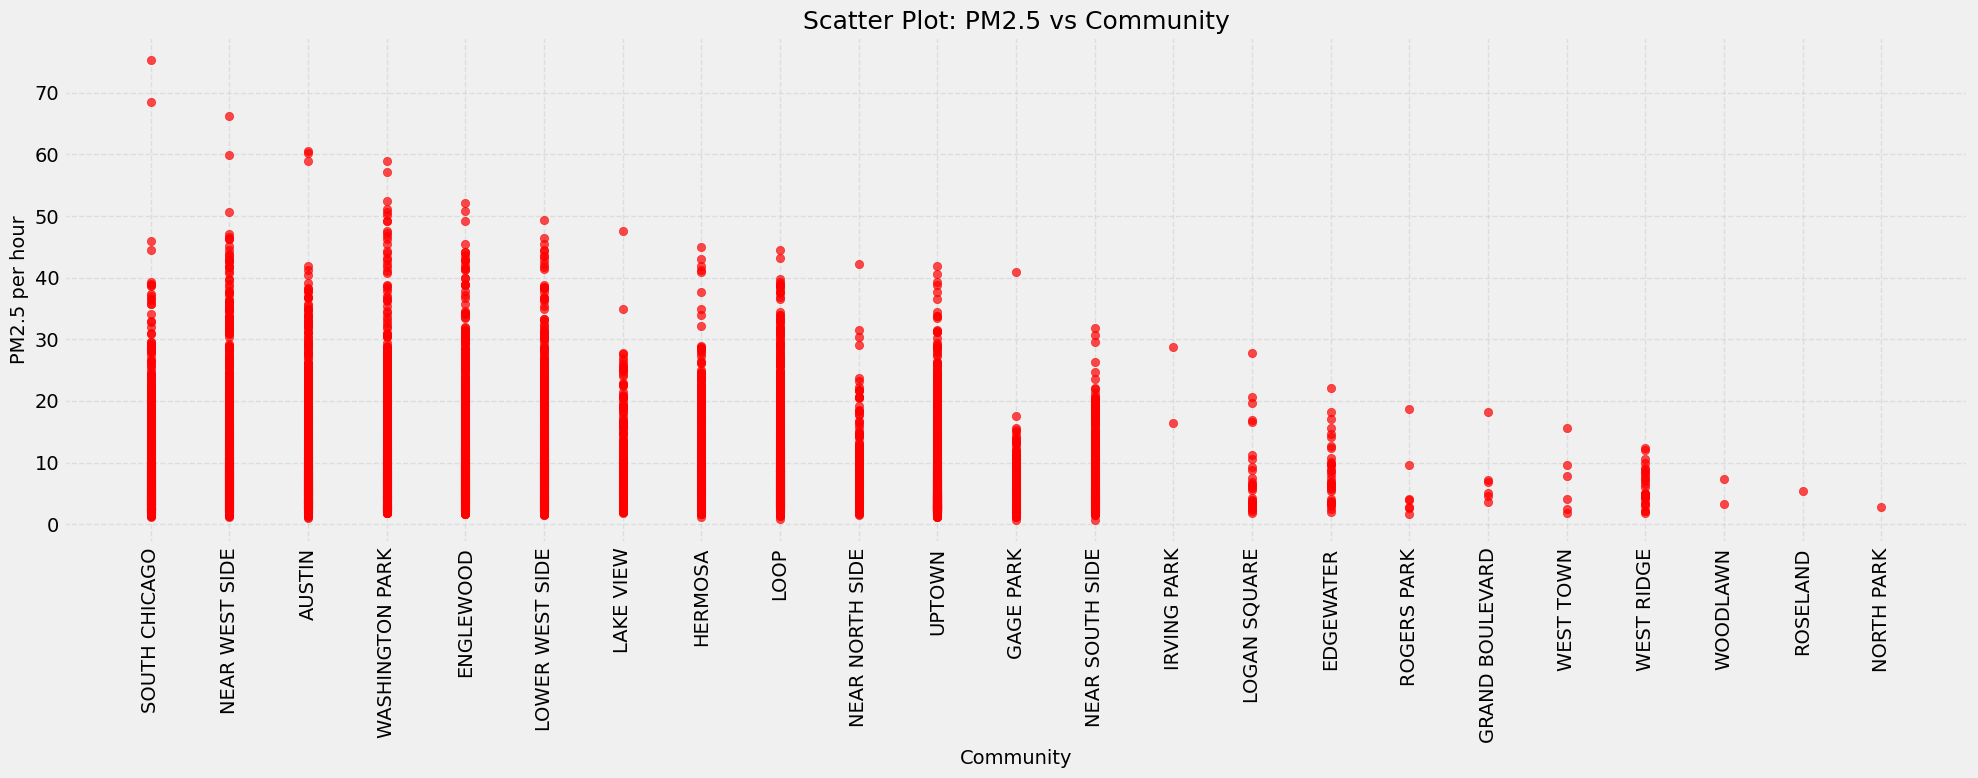

In [144]:
#Scatter Plot: PM2.5 vs Community
# Sort the data by PM2.5 for better visual order (optional)
joined_sorted = joined.sort_values(by='PM25', ascending=False)

#removeing outliers
joined_sorted = joined_sorted.where(joined['PM25'] < 90).dropna()


# Create the scatter plot
plt.figure(figsize=(20, 8))
plt.scatter(joined_sorted['community'], joined_sorted['PM25'], color='red', alpha=0.7)

# Titles and labels
plt.title('Scatter Plot: PM2.5 vs Community', fontsize=18)
plt.xlabel('Community', fontsize=14)
plt.ylabel('PM2.5 per hour', fontsize=14)

# Rotate x labels for better readability
plt.xticks(rotation=90)

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()




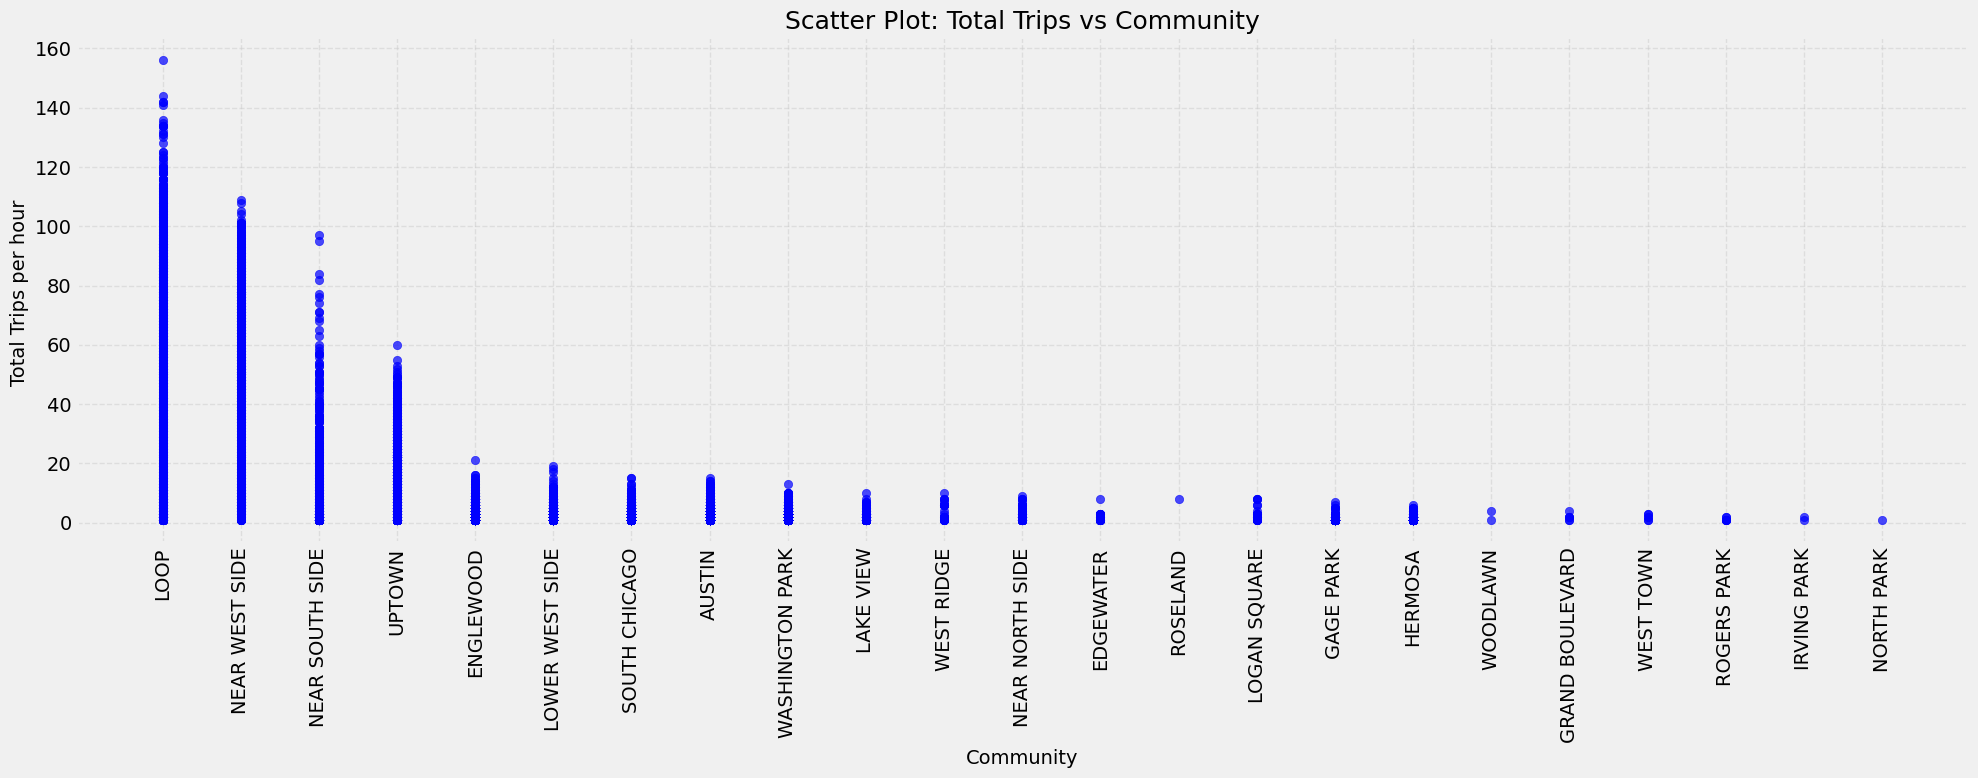

In [146]:

# Sort the data by total_trip_count for better visual order (optional)
joined_sorted = joined_sorted.sort_values(by='total_trip_count', ascending=False)

# Create the scatter plot
plt.figure(figsize=(20, 8))
plt.scatter(joined_sorted['community'], joined_sorted['total_trip_count'], color='blue', alpha=0.7)

# Titles and labels
plt.title('Scatter Plot: Total Trips vs Community', fontsize=18)
plt.xlabel('Community', fontsize=14)
plt.ylabel('Total Trips per hour ', fontsize=14)

# Rotate x labels for better readability
plt.xticks(rotation=90)

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


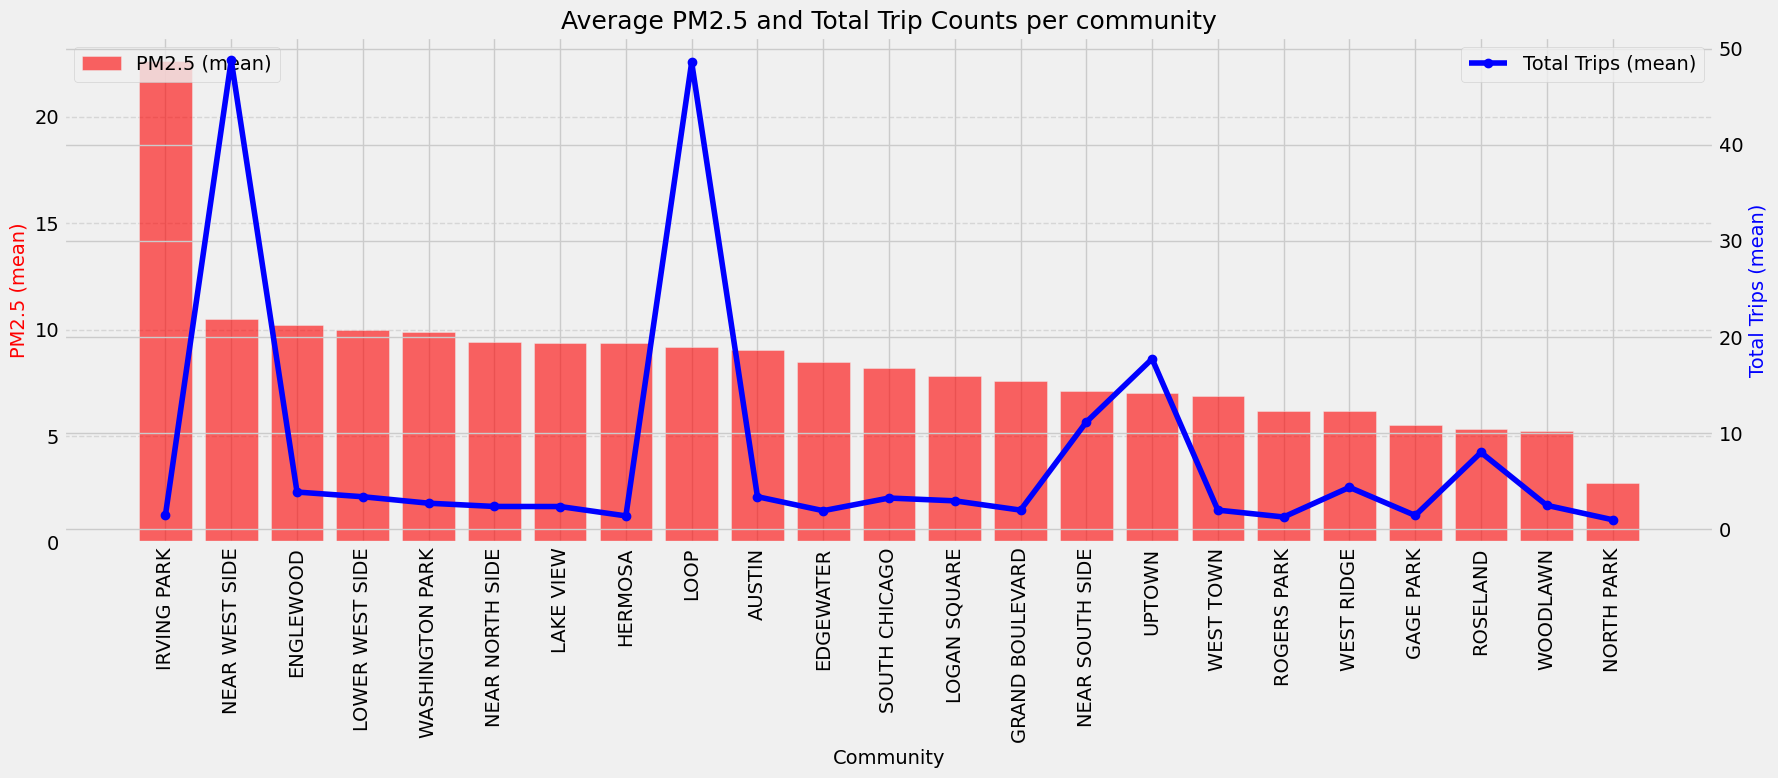

In [148]:
#Average PM2.5 and Total Trip Counts per community
%matplotlib inline

# Step 1: Aggregate by community using joined
community_summary = joined_sorted.groupby('community').agg({
    'PM25': 'mean',
    'total_trip_count': 'mean'}).reset_index()

# Step 2: Sort by PM2.5 (highest to lowest)
community_summary = community_summary.sort_values(by='PM25', ascending=False)

#plot
# Enlarge figure
fig, ax1 = plt.subplots(figsize=(18, 8))  # wider figure

# Bar plot for PM2.5
ax1.bar(community_summary['community'], community_summary['PM25'], color='red', alpha=0.6, label='PM2.5 (mean)')
ax1.set_ylabel('PM2.5 (mean)', color='red', fontsize=14)
ax1.set_xlabel('Community', fontsize=14)
ax1.tick_params(axis='x', rotation=90)  # rotate x labels vertically

# Add grid
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create second axis for trip counts
ax2 = ax1.twinx()
ax2.plot(community_summary['community'], community_summary['total_trip_count'], color='blue', marker='o', label='Total Trips (mean)')
ax2.set_ylabel('Total Trips (mean)', color='blue', fontsize=14)

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Average PM2.5 and Total Trip Counts per community', fontsize=18)
plt.tight_layout()
plt.show()


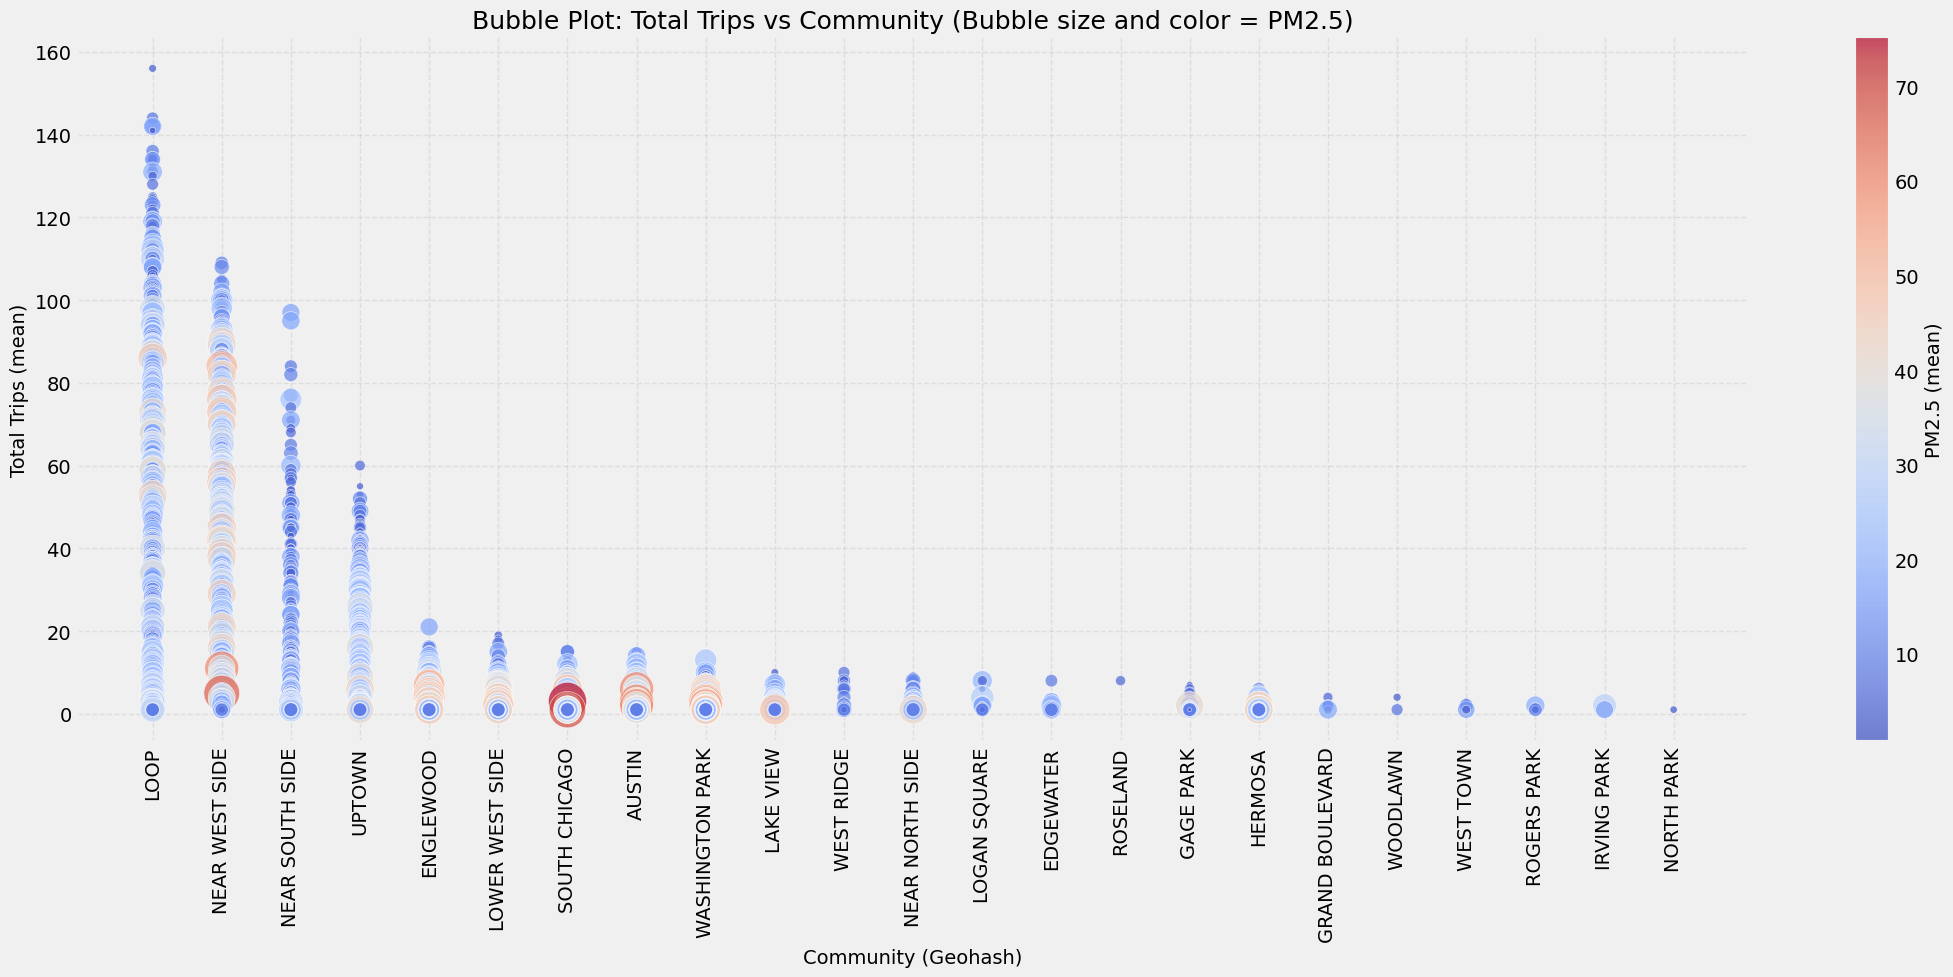

In [150]:


# Sort by total_trip_count for cleaner look (optional)
joined_sorted = joined_sorted.sort_values(by='total_trip_count', ascending=False)

# Create the bubble plot
plt.figure(figsize=(22, 10))
scatter = plt.scatter(
    joined_sorted['community'], 
    joined_sorted['total_trip_count'], 
    s=joined_sorted['PM25'] * 10,        # Bubble size (scaled)
    c=joined_sorted['PM25'],              # Bubble color
    cmap='coolwarm', 
    alpha=0.7, 
    edgecolors='w', 
    linewidth=0.5
)

# Titles and labels
plt.title('Bubble Plot: Total Trips vs Community (Bubble size and color = PM2.5)', fontsize=18)
plt.xlabel('Community (Geohash)', fontsize=14)
plt.ylabel('Total Trips (mean)', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('PM2.5 (mean)', fontsize=14)

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [136]:
joined_sorted #final joined cleaned table

,geohash,time_bin,pickup_trip_count,dropoff_trip_count,total_trip_count,Temperature,Humidity,PM25,CO,latitude,longitude,geometry,index_right,community
14289,dp3wq0,2021-09-23 18:00:00,84.0,72.0,156.0,18.219515,48.329417,3.119984,-8.763366,41.882629,-87.621460,POINT (-87.621 41.883),37.0,LOOP
14446,dp3wq0,2021-10-08 16:00:00,78.0,66.0,144.0,22.041588,74.874878,7.541146,-8.772865,41.882629,-87.621460,POINT (-87.621 41.883),37.0,LOOP
14438,dp3wq0,2021-10-07 18:00:00,80.0,62.0,142.0,20.956601,87.691151,13.242789,-8.771948,41.882629,-87.621460,POINT (-87.621 41.883),37.0,LOOP
14432,dp3wq0,2021-10-06 18:00:00,73.0,69.0,142.0,20.543289,81.053314,16.962333,-8.772314,41.882629,-87.621460,POINT (-87.621 41.883),37.0,LOOP
14268,dp3wq0,2021-09-22 18:00:00,73.0,68.0,141.0,17.558538,67.523055,2.077877,-8.763452,41.882629,-87.621460,POINT (-87.621 41.883),37.0,LOOP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14717,dp3wtm,2021-07-19 12:00:00,0.0,1.0,1.0,21.668415,78.936768,9.756662,0.254217,41.954041,-87.654419,POINT (-87.654 41.954),44.0,LAKE VIEW
300,dp3trw,2021-07-18 18:00:00,0.0,1.0,1.0,30.173505,59.838867,9.759611,0.296829,41.739807,-87.555542,POINT (-87.556 41.74),41.0,SOUTH CHICAGO
7651,dp3we8,2021-08-28 20:00:00,0.0,1.0,1.0,39.075356,42.961756,9.764706,0.300324,41.926575,-87.731323,POINT (-87.731 41.927),20.0,HERMOSA
301,dp3trw,2021-07-18 19:00:00,0.0,1.0,1.0,30.657050,57.849757,9.765494,0.271196,41.739807,-87.555542,POINT (-87.556 41.74),41.0,SOUTH CHICAGO
